# PyTorch Computer Vision

# computer vision libraries in PyTorch

* `torchvision` - contains datasets, model architectures and image transformation
* `torchvision.dataset` - get datasets and data loading functions for computer vision here
* `torchvision.models` - get prtrained vision models for leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for us with a ML model
* `torch.utils.data.Dataset` - Base Dataset class for PyTorch
* `torch.util.DataLoader` - Creates a Python iterable over a dataset

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# check versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


## 1. Getting a dataset

the dataset we will be using is Fashion.MNIST

In [2]:
# setup training data
train_data = datasets.FashionMNIST(
    root = 'data', # where to download data
    train = True, # do we want a training set
    download = True,
    transform = ToTensor(), # how do we want to transform the data
    target_transform = None # how do we want to transform the labels
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image, label = train_data[0] # COLOR CHANNEL, HEIGHT, WIDTH
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### Visualizing our data

Image shape: torch.Size([1, 28, 28])
Label: 9, Class: Ankle boot


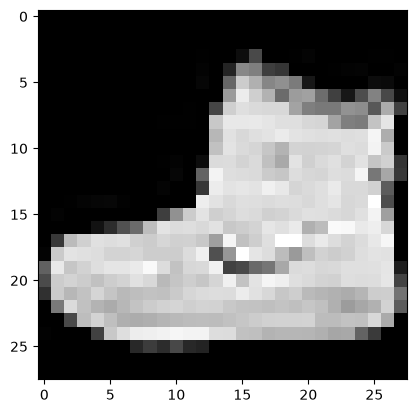

In [7]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}, Class: {class_names[label]}")
plt.imshow(image.squeeze(), cmap="gray")
# matplotlib expects data as h x w x c or just h x w for grey scale

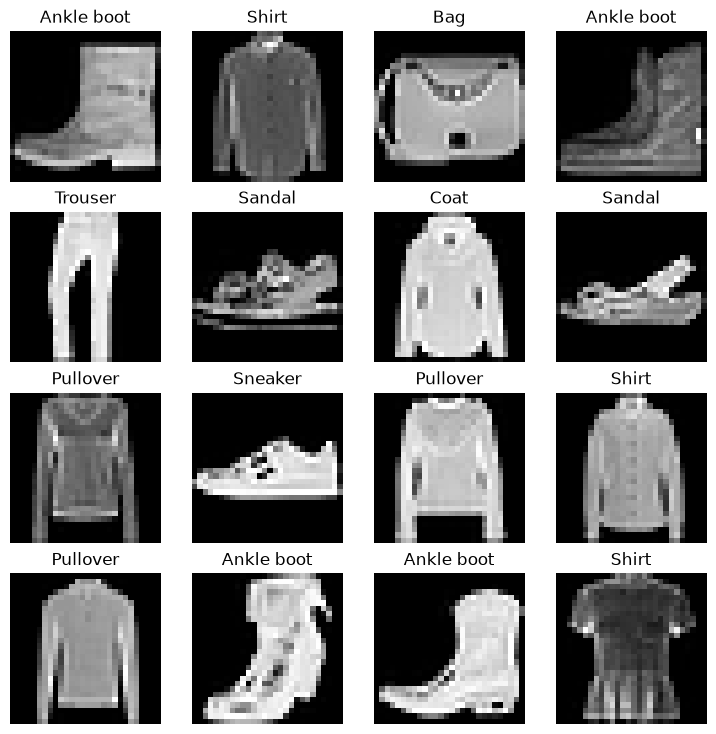

In [8]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows * cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(class_names[label])

## 2. Prepare DataLoader

Right now, our data is in the form of Pytorch Dataset

DataLoader turns our dataset into a Python iterable, so we can loop through it

we want to turn our data into mini batches.

why do we do this?

1. Its more computationally efficient, as in, your computing hardware may not be able to look (store in memory) at 6000 img in one hit. So we break it down to 32 img at a time (batch size of 32).
2. It gives our neural network more chances to update its gradients per epoch

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# turn dataset into iterable
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = True)

In [10]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7957a29ed5b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7957a2bdba70>)

In [11]:
print(f"Dataloader: {train_dataloader}\nLength: {len(train_dataloader)}\nType: {type(train_dataloader)}")
print(f"Dataloader: {test_dataloader}\nLength: {len(test_dataloader)}\nType: {type(test_dataloader)}")

Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7957a29ed5b0>
Length: 1875
Type: <class 'torch.utils.data.dataloader.DataLoader'>
Dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7957a2bdba70>
Length: 313
Type: <class 'torch.utils.data.dataloader.DataLoader'>


In [12]:
# Lets check out whats inside a traing dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6


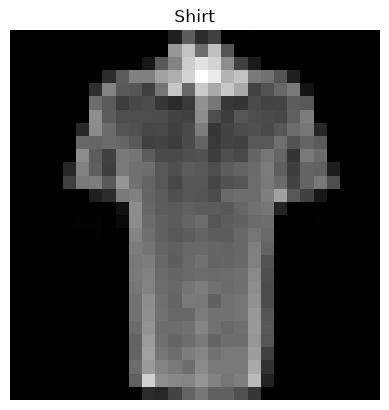

In [13]:
# show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = 'gray')
plt.title(class_names[label])
plt.axis('off')
print(f"Image size: {img.shape}")
print(f"Label: {label}")

## 3. Model 0: Building a baseline model

When starting to build a series of machine learning modelling experiments. best to start with a baseline model

In other words: start simple and add complexity when needed

In [14]:
# create a flatten layer
flatten_model = nn.Flatten()

# get single smaple
x= train_features_batch[0]

# flatten the sample
output = flatten_model(x)
print(f"Shape before flattening: {x.shape}\nShape after flattening: {output.shape}") # [color_channel, h, w] -> [color_channel, h*w]

Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])


In [15]:
from torch import nn
class FashionMNISTModel(nn.Module):
  def __init__(self,
               intput_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = intput_shape,
                  out_features = hidden_units),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
    )
  def forward(self, x):    return self.layer_stack(x)

In [16]:
torch.manual_seed

model_0 = FashionMNISTModel(
    intput_shape = 28*28,
    hidden_units = 10,
    output_shape = len(class_names)
).to("cpu")
model_0

FashionMNISTModel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [17]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[ 0.4283,  0.1136, -0.3903, -0.0246, -0.0698,  0.2508,  0.4007, -0.4172,
         -0.0264, -0.2463]], grad_fn=<AddmmBackward0>)

### 3.1 setup loss function, optimizer and evaluation metrics

* Loss function -  as its multi class data, we will use `nn.CrossEntropyLoss()`
* Optimizer - out optimizer `torch.optim.SGD()`
* Evaluation Metric - since we're workinf on classification problems, we will use accuracy as our eval.

In [18]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_function.py alreaady exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_function.py alreaady exists


In [19]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

### 3.2 Creating a function to time our experience

2 main things you'll often want to track are:
1. Models performance
2. How fast it runs

In [20]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time


### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss **per batch**
3. Loop through testing batches, perform training steps, calculate the test loss **per batch**
4. Print out whats happening
5. Time it out

In [21]:
# import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start = timer()

# Set the number of epochs (we'll keep it small for faster training time)
epochs = 3

# Create training test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")

  ### Training
  train_loss = 0
  # Add a loop to loop through the traning batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X)

    #2. Calculate the loss(per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # acculate train loss

    #3. Optimize zero grad

    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Print out whats happening
    if batch % 400 == 0:
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  # Divide total train loss by length of  train dataqaLoader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      test_pred = model_0(X_test)

      # 2. Calculate the loss
      test_loss += loss_fn(test_pred, y_test)

      # 3. Calculate accuracy
      test_acc += accuracy_fn(y_true = y_test,
                              y_pred = test_pred.argmax(dim = 1))

    # Calculate the test loss average per batch
    test_loss /=  len(test_dataloader)

    # Calculate the test acc average per batch
    test_acc /= len(test_dataloader)

  # Print out whats happening
  print(f"\nTrain loss: {train_loss:4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

# Calculate training time
train_time_end = timer()
total_train_time_model_0 = print_train_time(start = train_time_start,
                                            end = train_time_end,
                                            device = next(model_0.parameters()).device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.594837 | Test loss: 0.5170 | Test acc: 81.8291
Epoch: 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.477415 | Test loss: 0.5343 | Test acc: 81.3998
Epoch: 2
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.455520 | Test loss: 0.5168 | Test acc: 82.8874
Train time on cpu: 35.823 seconds


## 4. Make predictions and get Model 0 result

In [22]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device):
  """ Returns a dictionary containing the result of model predicting on data_loader."""
  loss, acc = 0, 0
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      # Make prediction
      y_pred = model(X)

      # Accumulate the loss and acc
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true = y,
                         y_pred = y_pred.argmax(dim = 1))
      # Scale loss andd acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
      "model_loss": loss.item(),
      "model_acc": acc}

  # Calculate model 0 results on test dataset
model_0_results = eval_model(model = model_0,
                               data_loader = test_dataloader,
                               loss_fn = loss_fn,
                               accuracy_fn = accuracy_fn,
                             device = "cpu")
model_0_results


{'model_name': 'FashionMNISTModel',
 'model_loss': 0.5161770582199097,
 'model_acc': 82.9173322683706}

## 5. Setup Device agnostic code


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non - linearity

In [24]:
## Create a non linear model and linear layers
class FashionMNISTV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_unit: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape,
                  out_features = hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features = hidden_unit,
                  out_features = hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features = hidden_unit,
                  out_features = output_shape),
        nn.ReLU()
        )
  def forward(self, x: torch.Tensor):
    return self.layer_stack(x)



In [25]:
# Create an instance model 1
torch.manual_seed(42)
model_1 = FashionMNISTV1(input_shape = 28*28,
                         hidden_unit = 10,
                         output_shape = len(class_names)).to(device)

In [26]:
next(model_1.parameters()).device, model_1

(device(type='cuda', index=0),
 FashionMNISTV1(
   (layer_stack): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=784, out_features=10, bias=True)
     (2): ReLU()
     (3): Linear(in_features=10, out_features=10, bias=True)
     (4): ReLU()
     (5): Linear(in_features=10, out_features=10, bias=True)
     (6): ReLU()
   )
 ))

### 1. loss, optimizer and evaluation metrics

In [27]:
from helper_functions import accuracy_fn as acc_fn
loss_fn = nn.CrossEntropyLoss()
optimizer =  torch.optim.SGD(params = model_1.parameters(),
                          lr = 0.1)

### 6.2 Functionizing and evaluation/ testig loops

Lets create a function for:
1. training_loop - `train_step`
2. testing loop - `test_step`

In [28]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim,
               acc_fn,
               device: torch.device = device):
  ### Training
  train_loss, train_acc = 0, 0
  # Add a loop to loop through the traning batches
  model.train()

  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    #2. Calculate the loss(per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # acculate train loss
    train_acc += acc_fn(y_true = y,
                        y_pred = y_pred.argmax(dim = 1))

    #3. Optimize zero grad

    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Print out whats happening
  #  if batch % 400 == 0:
  #    print(f"Looked at {batch*len(X)}/{len(data_loader.dataset)} samples")

  # Divide total train loss by length of  train dataqaLoader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:5f} | Train acc: {train_acc:.2f}")


In [29]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              acc_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculate the loss
      test_loss += loss_fn(test_pred, y)

      # 3. Calculate accuracy
      test_acc += acc_fn(y_true = y,
                              y_pred = test_pred.argmax(dim = 1))

    # Calculate the test loss average per batch
    test_loss /=  len(data_loader)

    # Calculate the test acc average per batch
    test_acc /= len(data_loader)



  # Print out whats happening
    print(f"\nTrain loss: {train_loss:4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

In [30]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

# set epochs
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  train_step(model = model_1,
              data_loader = train_dataloader,
              loss_fn = loss_fn,
              optimizer = optimizer,
              acc_fn = acc_fn,
             device = device)

  test_step(model = model_1,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            acc_fn = acc_fn,
            device = device)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start = train_time_start_on_gpu,
                                            end = train_time_end_on_gpu,
                                            device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.928364 | Train acc: 66.64

Train loss: 0.455520 | Test loss: 0.7101 | Test acc: 73.4125
Epoch: 1
------
Train loss: 0.581832 | Train acc: 78.94

Train loss: 0.455520 | Test loss: 0.5222 | Test acc: 81.7192
Epoch: 2
------
Train loss: 0.455772 | Train acc: 83.53

Train loss: 0.455520 | Test loss: 0.4898 | Test acc: 83.0272
Train time on cuda: 30.229 seconds


**Note:** Sometimes, dependiing on your data / hardware you might find that your model trains faster on CPU than on GPU.
why?
1. it could be that the overhead for copying data/model to gpu overweighs the compute benefits offered by it

In [31]:
# Get model_1 rsults dictionary
model_1_results = eval_model(model = model_1,
                              data_loader = test_dataloader,
                             loss_fn = loss_fn,
                              accuracy_fn = accuracy_fn,
                             device = device)
model_1_results

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.48935434222221375,
 'model_acc': 83.04712460063898}

## Model_2: Building a Convolution neural network

CNN's are also called ConvNets.

CNN's are known for their capabilities to find fatterns in visual data


In [32]:
# create a CNN
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  model from CNN explainer website.
  """

  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 =  nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*7*7,
                  out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x



In [33]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,
                              hidden_units = 20,
                              output_shape = len(class_names)).to(device)
model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=980, out_features=10, bias=True)
  )
)

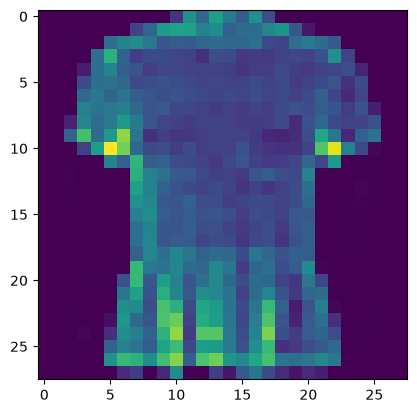

In [34]:
plt.imshow(image.squeeze())

In [35]:
model_2(image.unsqueeze(dim=0).to(device)
        )

tensor([[-0.0668, -0.0080, -0.0252,  0.0306, -0.0067,  0.0192,  0.0252, -0.0262,
         -0.0398,  0.0438]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.1 Stepping through `nn.Conv2d`

In [36]:
torch.manual_seed(42)

# Create a batch of images
img  = torch.rand(size = (32, 3, 64, 64))
test_img = img[0]
print(f"Shape of test image: {img.shape}")
print(f"Shape of single image: {test_img.shape}")
print(f"Test image:\n{test_img}")

Shape of test image: torch.Size([32, 3, 64, 64])
Shape of single image: torch.Size([3, 64, 64])
Test image:
tensor([[[0.8823, 0.9150, 0.3829,  ..., 0.1587, 0.6542, 0.3278],
         [0.6532, 0.3958, 0.9147,  ..., 0.2083, 0.3289, 0.1054],
         [0.9192, 0.4008, 0.9302,  ..., 0.5535, 0.4117, 0.3510],
         ...,
         [0.1457, 0.1499, 0.3298,  ..., 0.9624, 0.6400, 0.7409],
         [0.1709, 0.5797, 0.6340,  ..., 0.6885, 0.2405, 0.5956],
         [0.9199, 0.1247, 0.3573,  ..., 0.6752, 0.2058, 0.5027]],

        [[0.1458, 0.9024, 0.9217,  ..., 0.1868, 0.6352, 0.8431],
         [0.9549, 0.4435, 0.6924,  ..., 0.1168, 0.7160, 0.5462],
         [0.1616, 0.1054, 0.8614,  ..., 0.4531, 0.4736, 0.9448],
         ...,
         [0.4309, 0.3986, 0.1907,  ..., 0.9444, 0.2848, 0.3776],
         [0.7948, 0.6855, 0.1009,  ..., 0.6147, 0.7747, 0.2323],
         [0.5840, 0.9795, 0.3277,  ..., 0.3549, 0.1263, 0.1280]],

        [[0.5027, 0.4195, 0.8893,  ..., 0.3084, 0.1567, 0.7860],
         [0.731

In [37]:
# Create a single Conv2d layer
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size = 3,
                       stride = 1,
                       padding = 1)
conv_output = conv_layer(test_img)
conv_output.shape

torch.Size([10, 64, 64])

### 7.2 Stepping through `nn.MaxPool2d(`)

In [38]:
test_img.shape

torch.Size([3, 64, 64])

In [39]:
max_pool_layer = nn.MaxPool2d(kernel_size = 2)

# pass data through just the conv_layer
test_image_thru_conv = conv_layer(test_img)
print(f"shape after conv_layer: {test_image_thru_conv.shape} ")
test_image_thru_max_pool = max_pool_layer(test_image_thru_conv)
print(f"shape after conv_layer: {test_image_thru_max_pool.shape} ")

shape after conv_layer: torch.Size([10, 64, 64]) 
shape after conv_layer: torch.Size([10, 32, 32]) 


In [40]:
random_tesnor = torch.randn(size=(1,1,2,2))
print(f"\nRandom Tensor:\n{random_tesnor}")
print(f"\nRandom Tensor shape: {random_tesnor.shape}")
max_pool_layer = nn.MaxPool2d(kernel_size = 2)
max_pool_layer(random_tesnor)
print(f"\nMax pool output:\n{max_pool_layer(random_tesnor)}")
print(f"\nMax pool output shape: {max_pool_layer(random_tesnor).shape}")


Random Tensor:
tensor([[[[0.4963, 0.0045],
          [0.5534, 0.1379]]]])

Random Tensor shape: torch.Size([1, 1, 2, 2])

Max pool output:
tensor([[[[0.5534]]]])

Max pool output shape: torch.Size([1, 1, 1, 1])


In [41]:
image.shape

torch.Size([1, 28, 28])

### &.3 Setup a loss function and optimizer for `model_2`

In [42]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.1)

### 7.4 Training and testing `model_2` using our training and test function

In [43]:
# training loop for cnn model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
train_time_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  train_step(model = model_2,
             data_loader = train_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             acc_fn = acc_fn,
             device = device
             )

  test_step(model = model_2,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            acc_fn = acc_fn,
            device = device)

train_time_end = timer()
total_train_time = print_train_time(start = train_time_start, end = train_time_end, device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.544589 | Train acc: 80.15

Train loss: 0.455520 | Test loss: 0.3668 | Test acc: 86.7911
Epoch: 1
------
Train loss: 0.328246 | Train acc: 88.13

Train loss: 0.455520 | Test loss: 0.3728 | Test acc: 86.9509
Epoch: 2
------
Train loss: 0.288716 | Train acc: 89.56

Train loss: 0.455520 | Test loss: 0.3166 | Test acc: 88.7780
Train time on cuda: 38.761 seconds


In [44]:
model_2_results = eval_model(
    model = model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn,
    device = device
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3160052001476288,
 'model_acc': 88.7979233226837}

## 8. Comparing model results and training time

In [45]:
import pandas as pd
compare_results = pd.DataFrame(data = [model_0_results,
                                      model_1_results,
                                      model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModel,0.516177,82.917332
1,FashionMNISTV1,0.489354,83.047125
2,FashionMNISTModelV2,0.316005,88.797923


In [46]:
compare_results["training_time"] = [f"{total_train_time_model_0:.3f}",
                                    f"{total_train_time_model_1:.3f}",
                                    f"{total_train_time:.3f}"]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModel,0.516177,82.917332,35.823
1,FashionMNISTV1,0.489354,83.047125,30.229
2,FashionMNISTModelV2,0.316005,88.797923,38.761


Text(0, 0.5, 'model')

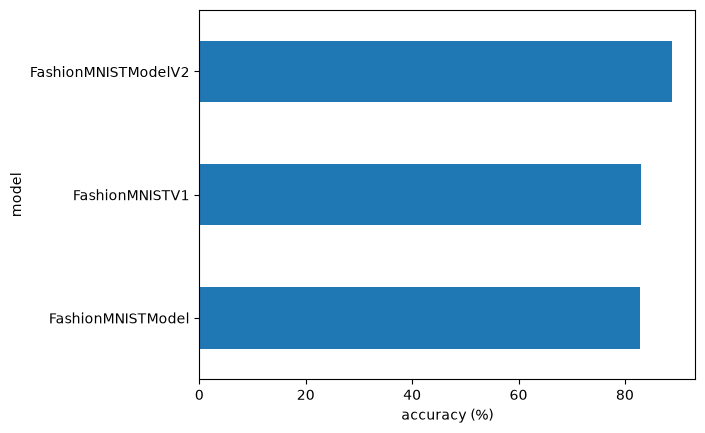

In [47]:
# visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind = "barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## 9. Make and evaluate random predictions with best model

In [48]:
def make_predicitions(model: torch.nn.Module,
                  data: list,
                  device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add a batch dimension ans pass to targer device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass (model optputs raw logits)
      pred_logits = model(sample)

      # Get prediciton probability (logit -> prediction probability)
      pred_prob = torch.softmax(pred_logits.squeeze(), dim = 0)

      # Get pred_probs off the gpu for further calculations
      pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into tensor
    return torch.stack(pred_probs)

In [49]:
img, label = test_data[0][:10]
img.shape, label

(torch.Size([1, 28, 28]), 9)

In [50]:
import random
#random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k =9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Shirt')

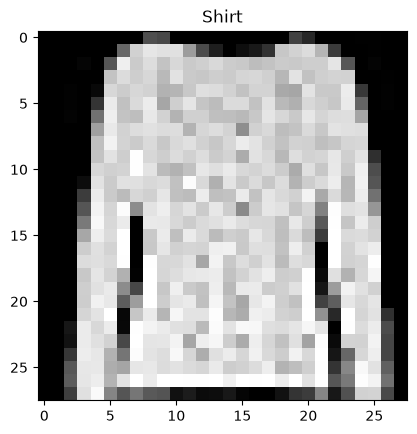

In [51]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]])

In [52]:
# make predicitons
pred_probs = make_predicitions(model = model_2,
                              data = test_samples,
                              )

# view first 2 prediciton probabilities
pred_probs[:2]

tensor([[5.5184e-02, 4.8681e-05, 8.7193e-01, 9.8875e-04, 1.2404e-03, 5.4412e-05,
         6.9898e-02, 8.9119e-06, 5.0797e-04, 1.3437e-04],
        [9.1064e-04, 4.3199e-05, 6.4378e-03, 2.8654e-04, 3.7588e-01, 6.4765e-06,
         6.1444e-01, 3.0709e-05, 1.8993e-03, 6.7377e-05]])

In [53]:
pred_classes = pred_probs.squeeze().argmax(dim=1)
pred_classes, test_labels

(tensor([2, 6, 1, 1, 7, 9, 1, 3, 5]), [6, 4, 1, 1, 7, 9, 1, 3, 5])

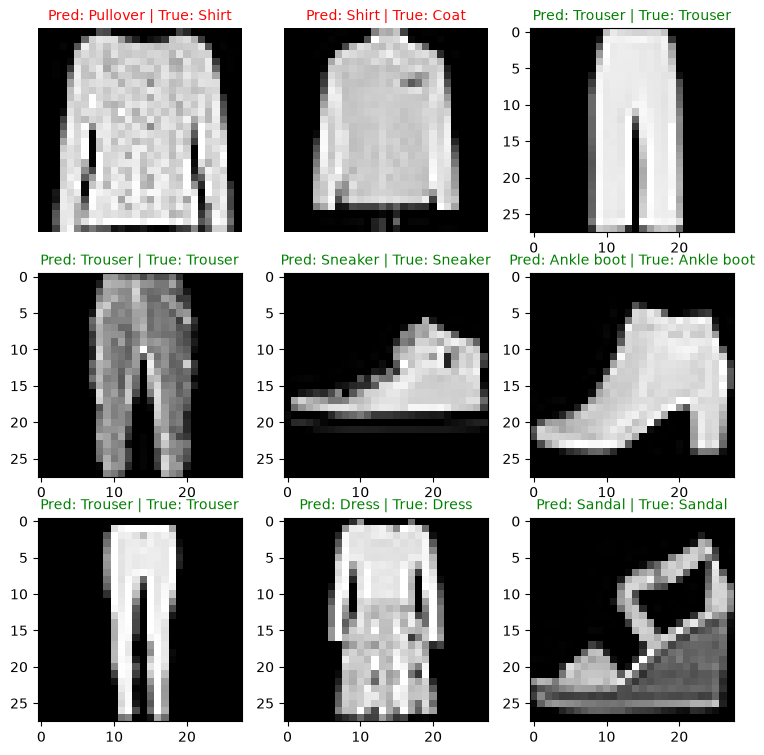

In [54]:
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
  # create subplot
  plt.subplot(nrows , ncols, i+1)
  plt.imshow(sample.squeeze(), cmap = "gray")

  # find the prediction(in tesxt form)
  pred_label = class_names[pred_classes[i]]
  true_label = class_names[test_labels[i]]

  # Create a title for the plot
  title_text = f"Pred: {pred_label} | True: {true_label}"
  if pred_label == true_label:
    plt.title(title_text, fontsize = 10, color = "green")
  else:
    plt.title(title_text, fontsize = 10, color = "red")
    plt.axis(False)

## 10. Making a confusion matrix foor further predicition evaluation

1. Make predicition with our trained model on the test dataset
2. Make a confusion matrix using `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [55]:
# import tqdm.auto
from tqdm.auto import tqdm
# 1. Make predicitons with trained model
y_preds = []
y_true = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc = "Making predicitons"):
    # Send data and targets to taqarget device
    X, y = X.to(device), y.to(device)

    # Do the forward pass
    y_logit = model_2(X)

    # Turn predicitons form logits -> prediction probabilities -> prediciton labels
    y_pred_prob = torch.softmax(y_logit.squeeze(), dim = 1)
    y_pred_label = y_pred_prob.argmax(dim = 1)
    # PUT PREDICITONS ON CPU
    y_preds.append(y_pred_label.cpu())
    y_true.append(y.cpu())

# Concatenate list of predicitons into a tesnor
#print(y_preds)
y_preds_tensor = torch.cat(y_preds)
y_true = torch.cat(y_true)
y_preds_tensor[:10],y_true[:10]

Making predicitons:   0%|          | 0/313 [00:00<?, ?it/s]

(tensor([2, 8, 6, 6, 8, 4, 2, 7, 6, 9]),
 tensor([2, 8, 6, 6, 8, 4, 2, 7, 0, 9]))

In [56]:
try:
  import torchmetrics, mlxtend
  print(f"torchmetrics version: {torchmetrics.__version__}")
  print(f"mlxtend version: {mlxtend.__version__}")
  assert mlxtend.__version__.split(".")[1] >= 19, "mlxtend version should be 1.19.0 or higher"
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"torchmetrics version: {torchmetrics.__version__}")
  print(f"mlxtend version: {mlxtend.__version__}")

torchmetrics version: 1.9.0
mlxtend version: 0.25.0
torchmetrics version: 1.9.0
mlxtend version: 0.25.0


In [57]:
import mlxtend, torchmetrics


In [58]:
test_data.targets

tensor([9, 2, 1,  ..., 8, 1, 5])

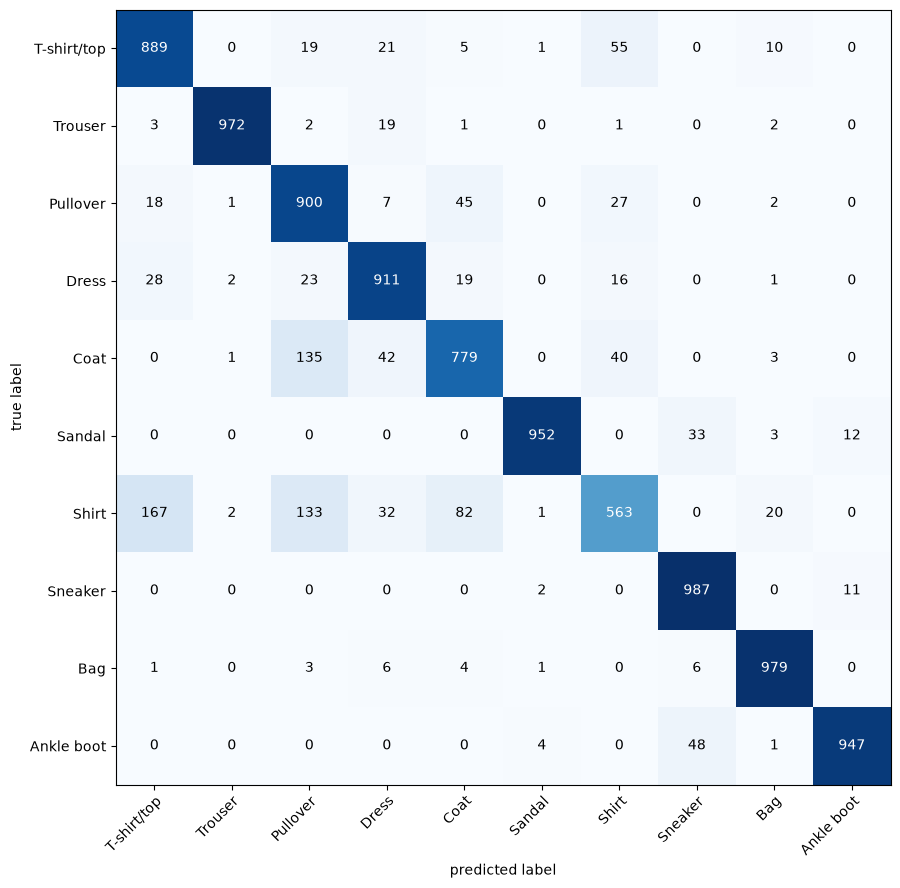

In [59]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix as plt_CM

# 2. Setup confusion instanse and compare predicitions to targets
confmat = ConfusionMatrix(num_classes = len(class_names), task = "multiclass")
confmat_tensor = confmat(preds = y_preds_tensor, target = y_true)

# 3. Plot the confusion matrix
fig, ax = plt_CM(
    conf_mat = confmat_tensor.numpy(), #matplot lib likes working with numpy
    figsize = (10,17),
    class_names = class_names
    #show_normed = True,
    #show_absolute = False
)

In [61]:
|confmat_tensor

SyntaxError: invalid syntax (3022496125.py, line 1)

## 11. Saving and loading best performing model

In [62]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,
                 exist_ok = True)

# Create nodel save
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state_dict()
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_2.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


In [63]:
# Create a new instance
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape = 1,
                                hidden_units = 20,
                                output_shape = len(class_names))

loaded_model_2.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=980, out_features=10, bias=True)
  )
)

In [64]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3160052001476288,
 'model_acc': 88.7979233226837}

In [65]:
# Evaluate loaded model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loaded_model_2_results = eval_model(
    model = loaded_model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn,
    device = device
)
loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.31597378849983215,
 'model_acc': 88.80790734824281}

In [66]:
# check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_acc"]), torch.tensor(loaded_model_2_results["model_acc"]), atol = 0.01)

tensor(True)